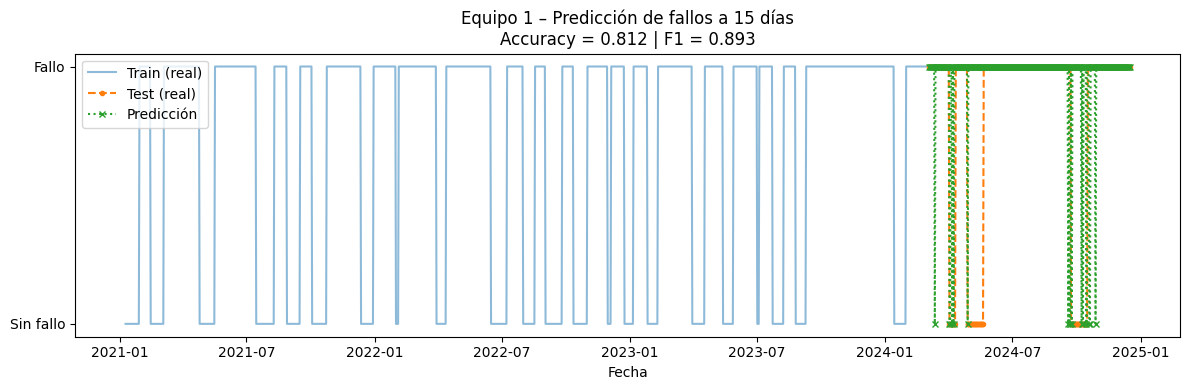

              precision    recall  f1-score   support

           0      0.562     0.161     0.250        56
           1      0.827     0.970     0.893       232

    accuracy                          0.812       288
   macro avg      0.695     0.565     0.571       288
weighted avg      0.776     0.812     0.768       288



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report


def cargar_equipo(csv_path: str, id_equipo: int, chunksize: int = 25_000) -> pd.DataFrame:
    """
    Carga de forma eficiente únicamente los registros del `id_equipo`
    indicado, leyendo el CSV por partes (chunks) para evitar problemas
    de memoria.
    """
    partes = []
    for chunk in pd.read_csv(
        csv_path, parse_dates=["Fecha"], chunksize=chunksize, engine="python"
    ):
        partes.append(chunk[chunk["ID_Equipo"] == id_equipo])
    return pd.concat(partes, ignore_index=True)


def etiquetar_fallos(df: pd.DataFrame, horizonte: int = 15) -> pd.DataFrame:
    """
    Añade la columna binaria `fallo_{horizonte}d` que vale 1 si en los
    siguientes `horizonte` días aparece un mantenimiento correctivo
    (Tipo_Mantenimiento == 1). Caso contrario 0.
    """
    df = df.sort_values("Fecha").reset_index(drop=True).copy()
    correctivos = (df["Tipo_Mantenimiento"] == 1).values
    etiqueta = np.full(len(df), np.nan)
    for i in range(len(df) - horizonte):
        etiqueta[i] = 1 if correctivos[i : i + horizonte].any() else 0
    df[f"fallo_{horizonte}d"] = etiqueta
    return df.dropna(subset=[f"fallo_{horizonte}d"])


def modelo_prediccion_fallos(
    csv_path: str,
    id_equipo: int,
    horizonte: int = 15,
    umbral: float = 0.30,
):
    """
    Entrena un RandomForest para anticipar fallos y muestra la gráfica
    de train / test / predicción junto con las métricas.
    """
    # 1) Carga eficiente
    df_eq = cargar_equipo(csv_path, id_equipo)
    if df_eq.empty:
        raise ValueError(f"No se encontraron datos para el equipo {id_equipo}")

    # 2) Etiquetado
    df_eq = etiquetar_fallos(df_eq, horizonte)

    # 3) Variables predictoras
    vars_sensor = [
        "Temperatura_C",
        "Vibracion_mm_s",
        "Horas_Operativas",
        "horas_hasta_correctivo",
    ]
    X = df_eq[vars_sensor].values
    y = df_eq[f"fallo_{horizonte}d"].astype(int).values

    # 4) División temporal 80/20
    corte = int(len(df_eq) * 0.8)
    X_train, X_test = X[:corte], X[corte:]
    y_train, y_test = y[:corte], y[corte:]
    fechas_train = df_eq["Fecha"].iloc[:corte]
    fechas_test = df_eq["Fecha"].iloc[corte:]

    # 5) Entrenamiento
    modelo = RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight="balanced"
    )
    modelo.fit(X_train, y_train)

    # 6) Predicción a partir del umbral deseado
    proba_test = modelo.predict_proba(X_test)[:, 1]
    y_pred = (proba_test >= umbral).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # 7) Visualización
    plt.figure(figsize=(12, 4))
    plt.plot(fechas_train, y_train, label="Train (real)", alpha=0.5)
    plt.plot(
        fechas_test, y_test, label="Test (real)", linestyle="--", marker="o", markersize=3
    )
    plt.plot(
        fechas_test,
        y_pred,
        label="Predicción",
        linestyle=":",
        marker="x",
        markersize=4,
    )
    plt.yticks([0, 1], ["Sin fallo", "Fallo"])
    plt.title(
        f"Equipo {id_equipo} – Predicción de fallos a {horizonte} días\n"
        f"Accuracy = {acc:.3f} | F1 = {f1:.3f}"
    )
    plt.xlabel("Fecha")
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    print(classification_report(y_test, y_pred, digits=3))
    return acc, f1


# ---------------- DEMOSTRACIÓN PARA EL EQUIPO 1 ----------------
accuracy, f1 = modelo_prediccion_fallos(
    "../data/Datos_limpios.csv", id_equipo=1, horizonte=15, umbral=0.30
)




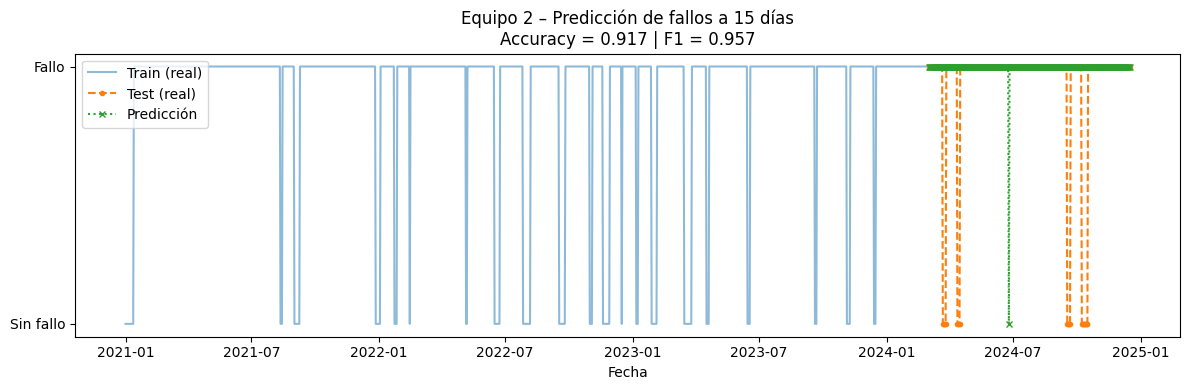

              precision    recall  f1-score   support

           0      0.000     0.000     0.000        23
           1      0.920     0.996     0.957       267

    accuracy                          0.917       290
   macro avg      0.460     0.498     0.478       290
weighted avg      0.847     0.917     0.881       290



In [5]:
accuracy, f1 = modelo_prediccion_fallos(
    "../data/Datos_limpios.csv",
    id_equipo=2,       # Elige el equipo para la predicción
    horizonte=15,
    umbral=0.30        # puedes afinarlo si lo necesitas
)
